In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"

import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2
import gc
from torchviz import make_dot
from sklearn.datasets import make_moons
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, utils
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

from torch.utils.data import DataLoader, TensorDataset


%matplotlib inline

# Agenda

1. [Model Weights Initialization](#Model_Weights_Initialization)
2. [LR Scheduling](#LR_Scheduling) 
3. [Model Regularization](#Model_Regularization)
4. [L1/L2 Penalties](#L1_L2_Penalties)
5. [Dropout](#Dropout)
6. [Batch/Layer Normalization](#Batch_Layer_Normalization)
7. [Other Types of Regularization](#Other_Types_of_Regularization)

# Resources
- [Chat with ChatGPT](https://chatgpt.com/share/68d19fc0-dcd0-8003-b4b5-9a2cd5d370bd)
- [Mastering Weight Initialization in Neural Networks: A Beginner’s Guide](https://medium.com/@piyushkashyap045/mastering-weight-initialization-in-neural-networks-a-beginners-guide-6066403140e9)
- [A Gentle Introduction to Learning Rate Schedulers](https://machinelearningmastery.com/a-gentle-introduction-to-learning-rate-schedulers/)
- [Regularization in Neural Networks](https://www.pinecone.io/learn/regularization-in-neural-networks/)
- [Deep Learning by Ian Goodfellow and Yoshua Bengio and Aaron Courville](https://www.deeplearningbook.org/)
- [Improving neural networks by preventing co-adaptation of feature detectors](https://arxiv.org/abs/1207.0580)
- [Understanding Dropout with the Simplified Math behind it](https://medium.com/data-science/simplified-math-behind-dropout-in-deep-learning-6d50f3f47275)
- [Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift](https://arxiv.org/abs/1502.03167)
- [Layer Normalization](https://arxiv.org/abs/1607.06450)

<a id='Model_Weights_Initialization'></a>
# Model Weights Initialization

# Why Do We Need Weights Initialization?

Weight initialization plays a **critical role** in training neural networks.  
A good initialization strategy ensures that signals (both activations and gradients) propagate properly through the layers.  
Poor initialization can lead to slow training, exploding gradients, or neurons that never learn.  

**Always remember that we are working with non-convex functions, so we can rely on a local minimum, which depends on starting point**

---

## 1. Symmetry Breaking
If all weights are initialized to the same value (e.g., all zeros), each neuron in a layer will compute the **same output** and receive the **same gradient update**:

$$
W_1 = W_2 = 0 \quad \Rightarrow \quad h_1 = h_2, \; \nabla W_1 = \nabla W_2
$$

This makes neurons redundant, preventing the network from learning diverse features.  
Random initialization solves this by introducing *asymmetry*.  

---

## 2. Avoiding Exploding or Vanishing Signals
Consider a deep network with linear activations.  
If weights are drawn from a distribution with variance $\sigma^2$, the variance of the output after $L$ layers becomes:

$$
Var(h^{(L)}) \approx (\sigma^2 n)^{L} \cdot Var(x)
$$

- If $\sigma^2 n > 1$: variance **explodes** exponentially with depth.  
- If $\sigma^2 n < 1$: variance **vanishes** exponentially with depth.  

---

## 3. Stable Gradient Flow
During backpropagation, gradients also suffer from the same problem.  
For example, if weights are too large:

$$
\nabla W^{(l)} \propto \prod_{k=l}^{L} W^{(k)}
$$

then the product of many large values causes **exploding gradients**, while many small values cause **vanishing gradients**.  

Good initialization ensures gradients have controlled variance, making optimization feasible.  

---

## 4. Faster Convergence
With well-chosen initialization:
- Activations stay in a useful range (not saturating sigmoid/tanh, not all-zero ReLUs).  
- Gradients remain balanced across layers.  
- Optimizers require fewer steps to converge.  

**In summary:** Weight initialization is not just about starting values — it is about ensuring *healthy signal propagation*, *stable gradients*, and *efficient learning* from the very first training step.  


In [2]:
# --- Data ---
# Taken from https://github.com/pytorch/examples/blob/main/mnist/main.py#L116
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
mnist_train = datasets.MNIST(root="../../data", train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root="../../data", train=False, download=True, transform=transform)

criterion = nn.CrossEntropyLoss()

# --- Model ---
class DeepMLP(nn.Module):
    def __init__(self):
        super(DeepMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 10)
        )
        
    def forward(self, x):
        x = x.view(-1, 28*28)
        return self.layers(x)

# --- Initialization Utility ---
def init_weights(m, init_type="xavier"):
    if isinstance(m, nn.Linear):
        if init_type == "xavier":
            nn.init.xavier_uniform_(m.weight)
        elif init_type == "he":
            nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
        elif init_type == "orthogonal":
            nn.init.orthogonal_(m.weight)
        elif init_type == "normal":
            nn.init.normal_(m.weight, mean=0.0, std=0.01)
        elif init_type == "zero":
            nn.init.zeros_(m.weight)
        # biases
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# --- Training Loop ---
def train_MNIST_check_init(
    init_type="xavier",
    batch_size=64,
    n_epoch=10,
    device="cuda"
):
    # PAY ATTENTION to `drop_last=True`
    train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)
    
    # Initialize model with chosen init
    model = DeepMLP().to(device)
    model.apply(lambda m: init_weights(m, init_type))
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    train_loss_hist = []
    val_loss_hist = []
    f1_hist = []
    
    for epoch in tqdm(range(n_epoch)):
        epoch_loss = 0.0
        model.train()
        
        for Xi, yi in train_loader:
            outputs = model(Xi.to(device))
            loss = criterion(outputs, yi.to(device))
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * Xi.shape[0]
        
        train_loss_hist.append(epoch_loss / len(mnist_train))

        # PAY ATTENTION to `model.eval()`
        model.eval()
        epoch_loss = 0.0
        all_preds, all_labels = [], []
        # PAY ATTENTION to `with torch.no_grad()`
        with torch.no_grad():
            for Xi, yi in test_loader:
                logits = model(Xi.to(device))
                loss = criterion(logits, yi.to(device))
                
                epoch_loss += loss.item() * Xi.shape[0]
                
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(yi.numpy())

        val_loss_hist.append(epoch_loss / len(mnist_test))
        f1_hist.append(f1_score(all_labels, all_preds, average="macro"))

    return train_loss_hist, val_loss_hist, f1_hist

def plot_metrics(train_losses, val_losses, f1_scores, init_names, lrs=None):
    """
    Plot Train Loss, Validation Loss, Validation F1, 
    and optionally Learning Rate for different initializations/schedulers.
    
    Args:
        train_losses (list of lists): each sublist is train loss history per init
        val_losses (list of lists): each sublist is val loss history per init
        f1_scores (list of lists): each sublist is F1 history per init
        init_names (list of str): names of initialization methods
        lrs (list of lists, optional): each sublist is LR history per init (per step)
    """
    
    epochs = range(1, len(train_losses[0]) + 1)
    
    # --- Train Loss ---
    plt.figure(figsize=(8,5))
    for losses, name in zip(train_losses, init_names):
        plt.plot(epochs, losses, label=f"{name} - Train")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss on MNIST")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
    
    # --- Validation Loss ---
    plt.figure(figsize=(8,5))
    for losses, name in zip(val_losses, init_names):
        plt.plot(epochs, losses, label=f"{name} - Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Loss on MNIST")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
    
    # --- Validation F1 ---
    plt.figure(figsize=(8,5))
    for f1, name in zip(f1_scores, init_names):
        plt.plot(epochs, f1, label=name)
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score (Macro)")
    plt.title("Validation F1 on MNIST")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
    
    # --- Learning Rate (Optional) ---
    if lrs is not None:
        plt.figure(figsize=(8,5))
        for lr_hist, name in zip(lrs, init_names):
            plt.plot(lr_hist, label=f"{name} - LR")
        plt.xlabel("Step")
        plt.ylabel("Learning Rate")
        plt.title("Learning Rate Schedule")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()



In [3]:
loss_train_zero, loss_val_zero, f1_zero = train_MNIST_check_init(init_type="zero", n_epoch=5)
loss_train_normal, loss_val_normal, f1_normal = train_MNIST_check_init(init_type="normal", n_epoch=5)
loss_train_he, loss_val_he, f1_he = train_MNIST_check_init(init_type="he", n_epoch=5)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:14<00:00, 14.87s/it]


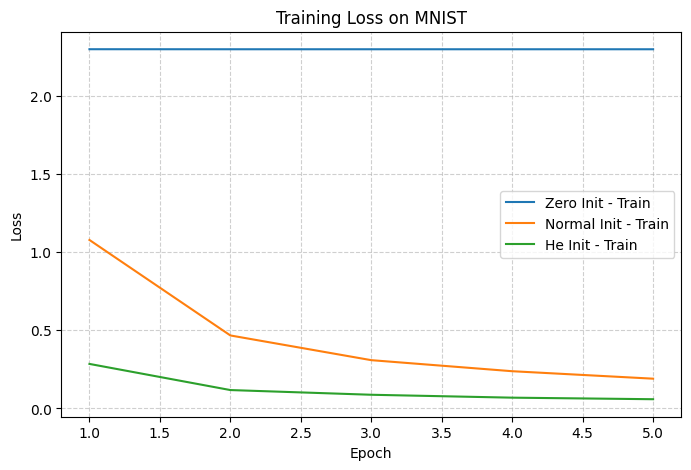

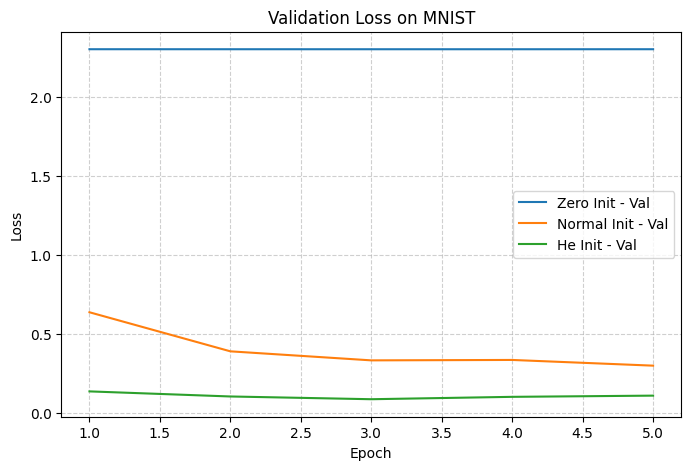

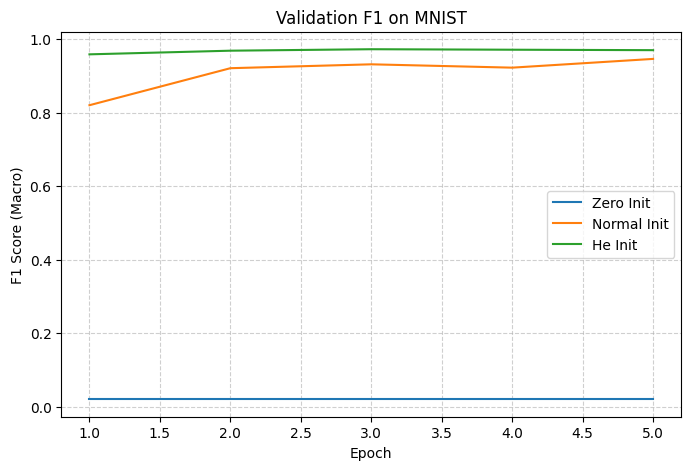

In [4]:
plot_metrics(
    train_losses=[loss_train_zero, loss_train_normal, loss_train_he],
    val_losses=[loss_val_zero, loss_val_normal, loss_val_he],
    f1_scores=[f1_zero, f1_normal, f1_he],
    init_names=["Zero Init", "Normal Init", "He Init"]
)

# Weight Initialization Techniques

Proper weight initialization ensures stable signal propagation, prevents vanishing/exploding gradients, and speeds up convergence.  
Here are the most common techniques:

---

## 1. Zero Initialization
- **Idea**: Set all weights to zero.  
- **Formula**:  
$$
W_{ij} = 0
$$
- **Problem**: All neurons in the same layer compute the same function → no symmetry breaking.  
- **Use case**: Rarely useful (sometimes only for bias terms).  

---

## 2. Random Normal / Uniform Initialization
- **Idea**: Initialize from small random values.  
- **Formulas**:
  - Uniform:  
    $$
    W_{ij} \sim U(-\epsilon, \epsilon)
    $$
  - Normal:  
    $$
    W_{ij} \sim \mathcal{N}(0, \sigma^2)
    $$
- **Problem**: Without scaling, variance may explode/vanish with depth.  

---

## 3. LeCun Initialization (for Sigmoid / Tanh, SELU)
- **Idea**: Keep variance of activations consistent for each layer.  
- **Formula**:
$$
Var(W) = \frac{1}{n_{\text{in}}}
$$
where $n_{\text{in}}$ = number of input units.  
- **Distribution**:  
  - Normal: $\mathcal{N}(0, \tfrac{1}{n_{\text{in}}})$  
  - Uniform: $U\Big(-\sqrt{\tfrac{3}{n_{\text{in}}}}, \; +\sqrt{\tfrac{3}{n_{\text{in}}}}\Big)$  

---

## 4. Xavier / Glorot Initialization (for Sigmoid, Tanh)
- **Idea**: Balance forward and backward variance (activations + gradients).  
- **Formula**:
$$
Var(W) = \frac{2}{n_{\text{in}} + n_{\text{out}}}
$$
- **Distribution**:  
  - Normal: $\mathcal{N}(0, \tfrac{2}{n_{\text{in}} + n_{\text{out}}})$  
  - Uniform: $U\Big(-\sqrt{\tfrac{6}{n_{\text{in}} + n_{\text{out}}}}, \; +\sqrt{\tfrac{6}{n_{\text{in}} + n_{\text{out}}}}\Big)$  

---

## 5. He / Kaiming Initialization (for ReLU, LeakyReLU)
- **Idea**: Account for ReLU dropping ~50% of activations.  
- **Formula**:
$$
Var(W) = \frac{2}{n_{\text{in}}}
$$
- **Distribution**:  
  - Normal: $\mathcal{N}(0, \tfrac{2}{n_{\text{in}}})$  
  - Uniform: $U\Big(-\sqrt{\tfrac{6}{n_{\text{in}}}}, \; +\sqrt{\tfrac{6}{n_{\text{in}}}}\Big)$  

---

## 6. Orthogonal Initialization
- **Idea**: Initialize weight matrix $W$ as an orthogonal matrix (preserves norms).  
- **Formula**:
$$
W^T W = I
$$
- **Benefit**: Prevents signal amplification/decay in very deep networks.  

---

## 7. LSUV (Layer-Sequential Unit-Variance)
- **Idea**: Data-driven method. Start with orthogonal init, then iteratively rescale weights using a batch of real data until activations have unit variance.  
- **Target**:
$$
Var(h^{(l)}) \approx 1
$$
- **Benefit**: Works well for very deep networks.  

---

✅ **Summary**:  
- Use **Xavier** for `tanh/sigmoid`.  
- Use **He** for `ReLU/LeakyReLU`.  
- Use **LeCun** for `SELU`.  
- Consider **Orthogonal / LSUV** for very deep architectures.  


In [6]:
loss_train_xavier, loss_val_xavier, f1_xavier = train_MNIST_check_init(init_type="xavier", n_epoch=5)
loss_train_orthogonal, loss_val_orthogonal, f1_orthogonal = train_MNIST_check_init(init_type="orthogonal", n_epoch=5)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:18<00:00,  3.69s/it]


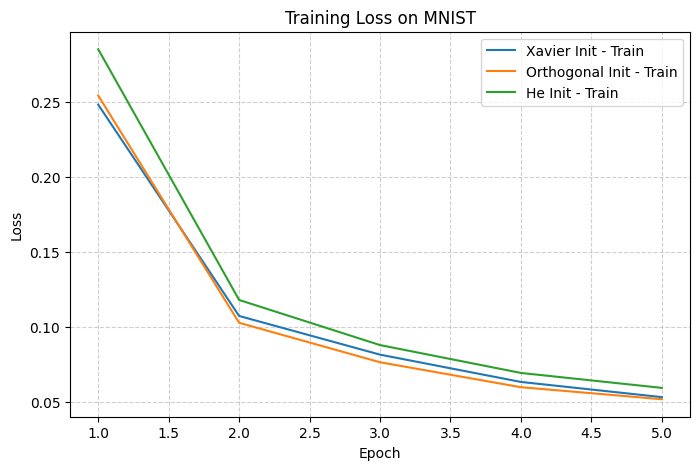

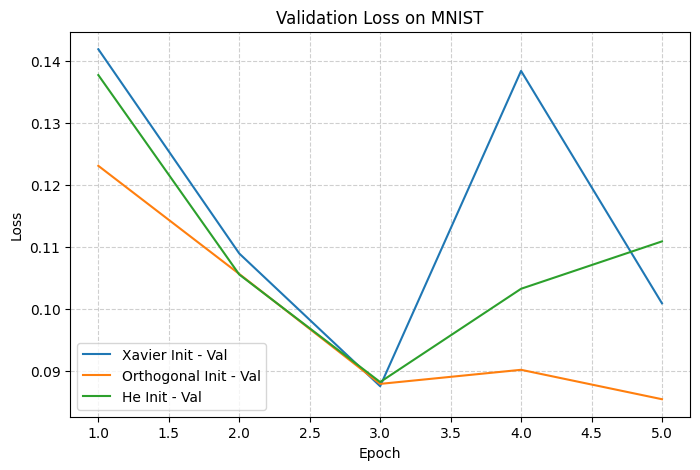

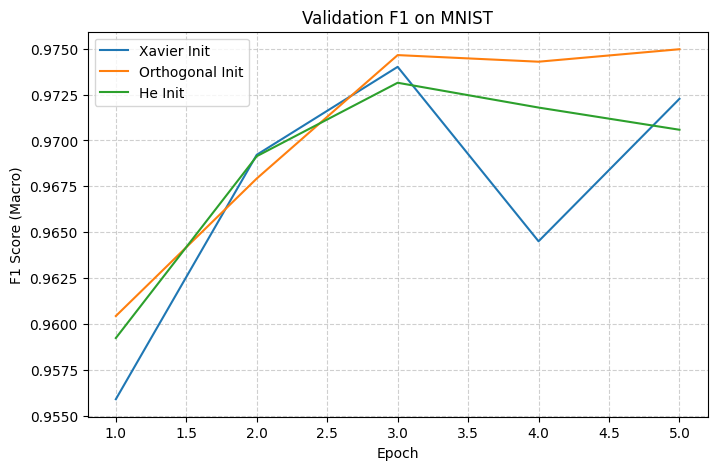

In [7]:
plot_metrics(
    train_losses=[loss_train_xavier, loss_train_orthogonal, loss_train_he],
    val_losses=[loss_val_xavier, loss_val_orthogonal, loss_val_he],
    f1_scores=[f1_xavier, f1_orthogonal, f1_he],
    init_names=["Xavier Init", "Orthogonal Init", "He Init"]
)

<a id='LR_Scheduling'></a>
# LR Scheduling

## Why Do We Need Learning Rate Scheduling?

The **learning rate (LR)** controls how much we update model weights during each optimization step.  
A fixed learning rate often leads to **suboptimal training** because different phases of training benefit from different update sizes.  

---

### Problems with a Fixed Learning Rate

1. **Too High LR**  
   - Training may **diverge** (loss oscillates or explodes).  
   - Example: with LR too large, updates overshoot the minimum.  
   - Gradient descent update rule:  
     $$
     w_{t+1} = w_t - \eta \nabla L(w_t)
     $$  
     If $\eta$ is too large → $w_{t+1}$ jumps back and forth without converging.

2. **Too Low LR**  
   - Training converges **very slowly**.  
   - Model may get stuck in sharp local minima or plateaus.  

---

### Benefits of Scheduling the Learning Rate

- **Faster Convergence**  
  Start with a relatively high LR for rapid progress, then reduce it for fine-tuning.  

- **Better Generalization**  
  Decaying the LR allows the optimizer to settle into **flatter minima**, which are linked to better test performance.  

- **Escaping Poor Minima / Saddle Points**  
  High LR early on helps escape narrow minima and saddle points.  

---

### Intuition in Training Dynamics

- Early epochs → **large steps** help explore the loss landscape.  
- Later epochs → **smaller steps** help refine and converge stably.  

A typical schedule might start with $\eta_0 = 0.1$ and decay towards $\eta \approx 10^{-4}$:  

$$
\eta_t = \eta_0 \cdot \gamma^t
$$

where $\gamma \in (0,1)$ is the decay factor.  

---

**In summary:** Learning Rate Scheduling adapts the step size during training to balance **exploration** (fast learning early) and **exploitation** (fine-tuning later), leading to more efficient and stable convergence.  


## Popular Learning Rate Scheduling Strategies

There are many strategies to adapt the learning rate during training.  
Below are the most widely used ones with their update rules:

---

### 1. Step Decay
- Reduce the learning rate by a factor every $k$ epochs.
- Formula:  
$$
\eta_t = \eta_0 \cdot \gamma^{\lfloor \tfrac{t}{k} \rfloor}
$$
where  
- $\eta_0$ = initial LR,  
- $\gamma$ = decay factor (e.g., 0.1),  
- $t$ = current epoch,  
- $k$ = step size in epochs.

![Image Title](images/StepLR.png)
*Taken from [Pytorch Documentation](https://docs.pytorch.org/docs/2.8/generated/torch.optim.lr_scheduler.StepLR.html)*

---

### 2. Exponential Decay
- Learning rate decays continuously by a factor per epoch.
- Formula:  
$$
\eta_t = \eta_0 \cdot e^{-\lambda t}
$$
where $\lambda$ is the decay rate.

![Image Title](images/ExponentialLR.png)
*Taken from [Pytorch Documentation](https://docs.pytorch.org/docs/2.8/generated/torch.optim.lr_scheduler.ExponentialLR.html)*

---

### 3. Polynomial Decay
- Learning rate decays polynomially towards a minimum value.
- Formula:  
$$
\eta_t = \eta_{min} + (\eta_0 - \eta_{min}) \cdot \Big(1 - \frac{t}{T}\Big)^p
$$
where  
- $T$ = total training epochs,  
- $p$ = polynomial power (e.g., $p=2$ for quadratic).

![Image Title](images/PolynomialLR.png)
*Taken from [Pytorch Documentation](https://docs.pytorch.org/docs/2.8/generated/torch.optim.lr_scheduler.PolynomialLR.html)*

---

### 4. Cosine Annealing
- Learning rate follows a cosine curve, gradually decreasing and sometimes restarting.
- **Usage: Used as a baseline in many tasks, especially classification/regression ones**
- Formula:  
$$
\eta_t = \eta_{min} + \tfrac{1}{2} (\eta_0 - \eta_{min}) \Big(1 + \cos\Big(\tfrac{\pi t}{T}\Big)\Big)
$$

![Image Title](images/CosineAnnealingLR.png)
*Taken from [Pytorch Documentation](https://docs.pytorch.org/docs/2.8/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html)*

---

### 5. Cyclical Learning Rate (CLR)
- LR cycles between lower and upper bounds, often improving generalization.
- Formula:  
$$
\eta_t = \eta_{min} + (\eta_{max} - \eta_{min}) \cdot f(t)
$$
where $f(t)$ is a triangular or cosine-shaped function.

![Image Title](images/CyclicLR.png)
*Taken from [Pytorch Documentation](https://docs.pytorch.org/docs/2.8/generated/torch.optim.lr_scheduler.CyclicLR.html)*

---

### 6. OneCycle Policy
- Start small, increase LR rapidly, then decay below initial value.
- Typically paired with momentum scheduling.  
- Formula (simplified):  
$$
\eta_t =
\begin{cases}
\eta_{min} + \tfrac{t}{t_{up}}(\eta_{max} - \eta_{min}), & t \leq t_{up} \\
\eta_{max} \cdot \Big(1 - \tfrac{t - t_{up}}{T - t_{up}}\Big), & t > t_{up}
\end{cases}
$$
where $t_{up}$ = warmup steps, $T$ = total steps.

![Image Title](images/OneCycleLR.png)
*Taken from [Pytorch Documentation](https://docs.pytorch.org/docs/2.8/generated/torch.optim.lr_scheduler.OneCycleLR.html)*

---

### 7. Warmup (Pre-Schedule Trick)
- Start with a very small LR and increase it linearly for the first few steps.  
- Formula:  
$$
\eta_t = \eta_{max} \cdot \frac{t}{t_{warmup}}, \quad t \leq t_{warmup}
$$
Then switch to another schedule (cosine, step, etc.).

![Image Title](images/warmup_linear_schedule.png)
*Taken from [Huggingface Documentation](https://huggingface.co/docs/transformers/main_classes/optimizer_schedules#transformers.get_linear_schedule_with_warmup)*

---

**Summary**:  
- **Step/Exponential decay** → simple, often used in CNNs.  
- **Cosine annealing / OneCycle** → popular in modern deep learning (ResNets, Transformers).  
- **Warmup** → critical for training very deep models (e.g., BERT, GPT).  


In [8]:
def train_MNIST_check_scheduler(
    batch_size=64,
    n_epoch=10,
    device="cuda",
    scheduler_cls=None,
    scheduler_params=None,
):
    # PAY ATTENTION to `drop_last=True`
    train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)
    
    # Initialize model with chosen init
    model = DeepMLP().to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    scheduler = None
    if scheduler_cls is not None:
        scheduler = scheduler_cls(optimizer, **(scheduler_params or {}))
    
    train_loss_hist = []
    val_loss_hist = []
    f1_hist = []
    lr_hist = [optimizer.param_groups[0]['lr']]
    
    for epoch in tqdm(range(n_epoch)):
        epoch_loss = 0.0
        model.train()
        
        for Xi, yi in train_loader:
            outputs = model(Xi.to(device))
            loss = criterion(outputs, yi.to(device))
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if scheduler is not None:
                scheduler.step()
                lr_hist.append(optimizer.param_groups[0]['lr'])
            else:
                lr_hist.append(optimizer.param_groups[0]['lr'])
            
            epoch_loss += loss.item() * Xi.shape[0]
        
        train_loss_hist.append(epoch_loss / len(mnist_train))

        # PAY ATTENTION to `model.eval()`
        model.eval()
        epoch_loss = 0.0
        all_preds, all_labels = [], []
        # PAY ATTENTION to `with torch.no_grad()`
        with torch.no_grad():
            for Xi, yi in test_loader:
                logits = model(Xi.to(device))
                loss = criterion(logits, yi.to(device))
                
                epoch_loss += loss.item() * Xi.shape[0]
                
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(yi.numpy())

        val_loss_hist.append(epoch_loss / len(mnist_test))
        f1_hist.append(f1_score(all_labels, all_preds, average="macro"))

    return train_loss_hist, val_loss_hist, f1_hist, lr_hist

In [9]:
loss_train_no_sched, loss_val_no_sched, f1_no_sched, lr_no_sched = train_MNIST_check_scheduler(n_epoch=10)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:50<00:00,  5.05s/it]


In [10]:
loss_train_steplr, loss_val_steplr, f1_steplr, lr_steplr = train_MNIST_check_scheduler(
    n_epoch=10,
    scheduler_cls=torch.optim.lr_scheduler.StepLR,
    scheduler_params={"step_size": len(mnist_train)//64, "gamma": 0.5}
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:46<00:00,  4.61s/it]


In [11]:
loss_train_onecycle, loss_val_onecycle, f1_onecycle, lr_onecycle = train_MNIST_check_scheduler(
    n_epoch=10,
    scheduler_cls=torch.optim.lr_scheduler.OneCycleLR,
    scheduler_params={
        "max_lr": 0.01,
        "steps_per_epoch": len(mnist_train)//64,
        "epochs": 10
    }
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:52<00:00,  5.29s/it]


In [12]:
loss_train_cosine, loss_val_cosine, f1_cosine, lr_cosine = train_MNIST_check_scheduler(
    n_epoch=10,
    scheduler_cls=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_params={
        "T_max": (len(mnist_train)//64) * 10,
        "eta_min": 1e-5
    }
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:44<00:00,  4.50s/it]


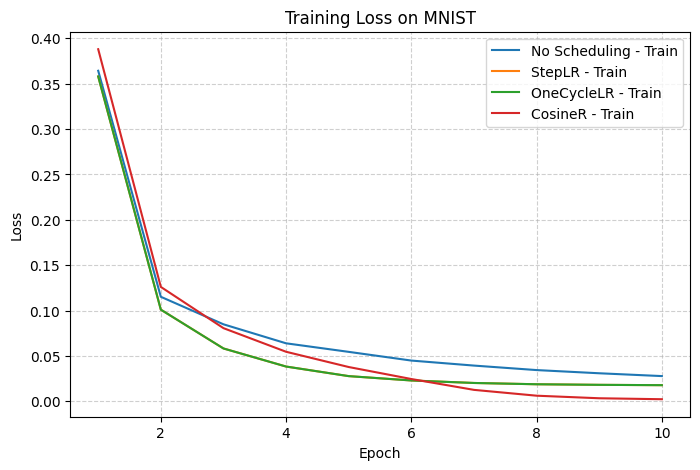

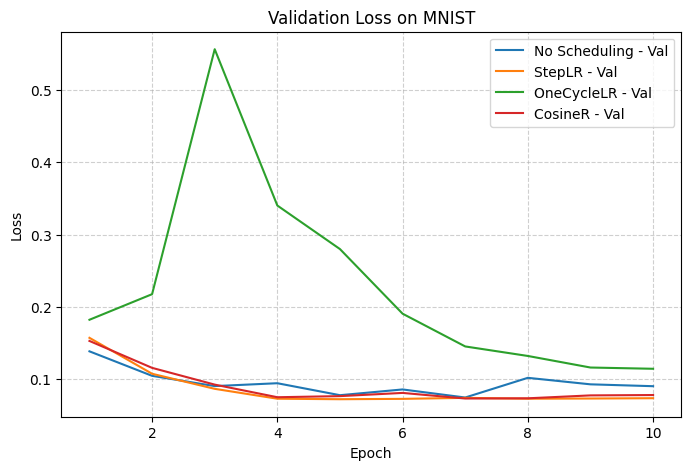

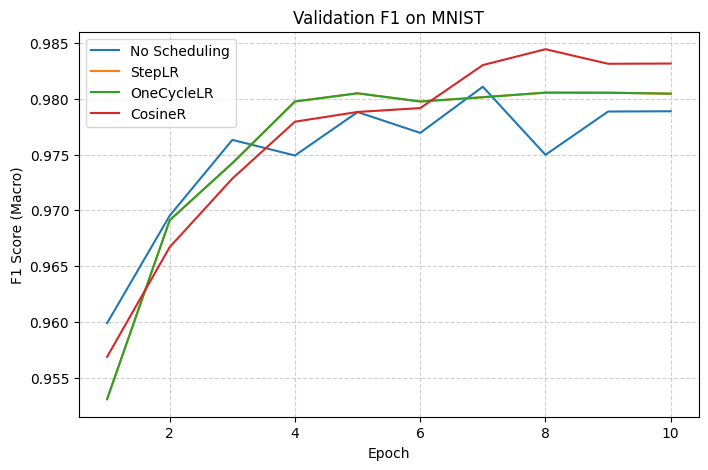

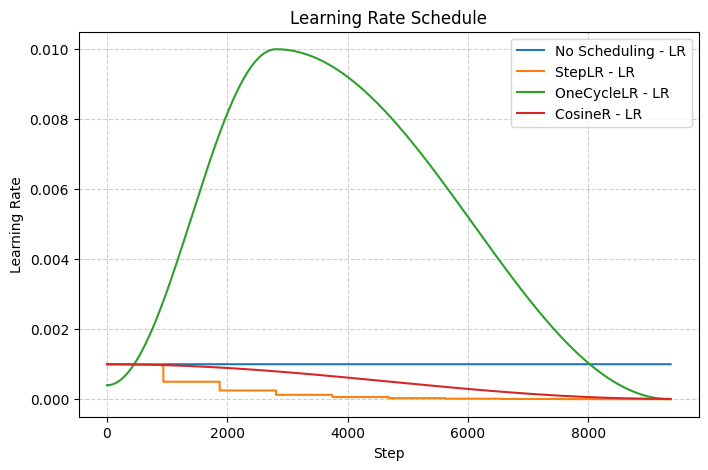

In [13]:
plot_metrics(
    train_losses=[loss_train_no_sched, loss_train_steplr, loss_train_steplr, loss_train_cosine],
    val_losses=[loss_val_no_sched, loss_val_steplr, loss_val_onecycle, loss_val_cosine],
    f1_scores=[f1_no_sched, f1_steplr, f1_steplr, f1_cosine],
    init_names=["No Scheduling", "StepLR", "OneCycleLR", "CosineR"],
    lrs=[lr_no_sched, lr_steplr, lr_onecycle, lr_cosine]
)

## ReduceLROnPlateau

Unlike schedulers with a predefined schedule (StepLR, CosineAnnealingLR, etc.),  
**ReduceLROnPlateau** adjusts the learning rate *based on validation performance*.  

---

### How it Works
- Monitor a chosen metric (commonly validation loss).  
- If the metric does **not improve** for a fixed number of epochs (`patience`), reduce the learning rate by a factor.  

**Formula:**
$$
\eta_{t+1} =
\begin{cases}
\eta_t \cdot \gamma, & \text{if no improvement for $p$ epochs} \\
\eta_t, & \text{otherwise}
\end{cases}
$$  

where  
- $\gamma < 1$ is the reduction factor (e.g., 0.1),  
- $p$ is the patience value.  

---

### Advantages
- Adaptive — no need to guess decay schedule ahead of time.  
- Useful when the training curve has **plateaus** or unknown dynamics.  
- Commonly used in computer vision and NLP training pipelines.  

---

### Potential Pitfall: Overfitting to Validation
Since **ReduceLROnPlateau monitors the validation set directly**,  
the optimizer’s learning rate schedule may **overfit to the validation signal**:  

- If the validation set is small, noisy, or unrepresentative → the LR may drop prematurely.  
- Too frequent adjustments can **optimize specifically for validation performance** instead of true generalization.  

---

**Summary**:  
`ReduceLROnPlateau` is powerful and adaptive, but it should be used carefully:  
- Ensure the validation set is large and representative.  
- Consider using a separate *test set* to avoid biasing results.  
- **In research, fixed schedules (Cosine Annealing, OneCycle) are often preferred to avoid this subtle form of overfitting.**

**Rule of Thumb: Use `ReduceLROnPlateau` in order to guess "the form" of optimal LR Scheduling curve than adopt other Schedulers parameters to "reproduce" it**


<a id='Model_Regularization'></a>
# Model Regularization

## Capacity, Overfitting and Underfitting

This section of *Deep Learning* (Goodfellow, Bengio, Courville) introduces the ideas of **model capacity** and the balance between **underfitting** and **overfitting**.

---

### Capacity
- **Capacity** = how complex the functions are that a model can represent.
    - hypothesis space - is based on a fixed function "form" and on a varying number of parameters
    - representational capacity - is based on a fixed number of parameters and on a verying function "form" and optimization algorithm
- Depends on model size, architecture, and number of parameters.  
- **Effective capacity** may be smaller than theoretical capacity due to optimization limits or regularization.  

---

### Underfitting
- Happens when the model capacity is **too small**.  
- Model fails to capture important structure in the data.  
- Symptoms:  
  - Training error is **high**  
  - Validation/test error is also **high**  

---

### Overfitting
- Happens when the model capacity is **too large** relative to the dataset.  
- Model fits not only the signal, but also **noise** and idiosyncrasies in the training set.  
- Symptoms:  
  - Training error is **low**  
  - Validation/test error is **high**  

---

![Image Title](images/over_under_fitting.png)
*Taken from [Goodfellow et al., Deep learning, MIT Press, 2016 Chapter 5](https://www.deeplearningbook.org/contents/ml.html)*

### Occam’s razor principle
- **This principle states that among competing hypotheses that explain known observations equally well, we should choose the “simplest” one**

---

### Generalization Trade-off
- Our goal is to minimize **generalization error** (performance on unseen data), not just training error.  
- For a fixed dataset size:
  - Too little capacity → underfitting  
  - Too much capacity → overfitting  
- The “sweet spot” is where model capacity is **just right** for the available data.  

---

![Image Title](images/generalization_gap.png)
*Taken from [Goodfellow et al., Deep learning, MIT Press, 2016 Chapter 5](https://www.deeplearningbook.org/contents/ml.html)*

### Capacity vs Dataset Size
- The right level of capacity depends on the amount of training data.  
- With more data, a higher-capacity model can be trained without overfitting.  
- With limited data, too much capacity leads quickly to overfitting.  

---

### Bayes Error

No matter how large a model’s capacity is, there is a fundamental **lower bound** on the error it can achieve: the **Bayes error** (also called Bayes risk).  

- The Bayes error reflects the **irreducible error** that comes from inherent noise or uncertainty in the data distribution.  
- Even the **Bayes optimal classifier**, which knows the true data distribution, cannot do better than this limit.  
- **Key point:** The Bayes error defines the **best achievable performance** for a given task. Our models should aim to approach it, while balancing capacity to avoid underfitting and overfitting.

---

### No Free Lunch Theorem

The **No Free Lunch (NFL) theorem** states that **no single learning algorithm is universally best** across all possible problems.  

- If an algorithm performs well on some tasks, it must perform worse on others.  
- Formally, averaged over all possible data-generating distributions, **all algorithms have the same expected performance**.  
- This means:
  - There is **no universally optimal model** or initialization strategy.  
  - Success depends on **matching model assumptions and capacity** to the specific data distribution.  
- **Key point:** The NFL theorem reminds us that there is no “one-size-fits-all” solution in machine learning. Choosing architectures, initialization, and training strategies must be guided by knowledge of the problem domain and data.

---

**Summary:**  
- **Underfitting** → high training & test error (model too simple).  
- **Overfitting** → low training error but high test error (model too complex).  
- Choosing the right **capacity–data balance** is key to achieving good generalization.


In [14]:
loss_train_overfit, loss_val_overfit, f1_overfit, lr_overfit = train_MNIST_check_scheduler(
    n_epoch=40,
    scheduler_cls=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_params={
        "T_max": (len(mnist_train)//64) * 40,
        "eta_min": 1e-5
    }
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [03:14<00:00,  4.85s/it]


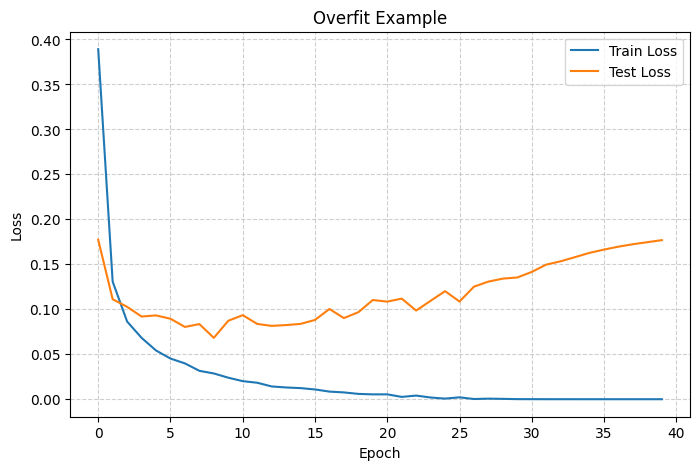

In [15]:
plt.figure(figsize=(8,5))
plt.plot(loss_train_overfit, label="Train Loss")
plt.plot(loss_val_overfit, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overfit Example")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Bias–Variance Trade-off

### Bias

The **bias** of an estimator $\hat{\theta}_m$ measures how far, on average, the estimator is from the true parameter $\theta$:  

$$
\text{bias}(\hat{\theta}_m) = \mathbb{E}[\hat{\theta}_m] - \theta
$$

- An estimator is **unbiased** if $\text{bias}(\hat{\theta}_m) = 0$, i.e. its expected value equals the true value.  
- It is **asymptotically unbiased** if the bias tends to zero as the number of samples $m \to \infty$.  

---

### Variance

The **variance** of an estimator $\hat{\theta}_m$ measures how much the estimate fluctuates depending on the specific dataset sampled:  

$$
\text{Var}(\hat{\theta}_m) = \mathbb{E}\Big[\big(\hat{\theta}_m - \mathbb{E}[\hat{\theta}_m]\big)^2\Big]
$$

- High variance means the model is very sensitive to training data noise.  
- Low variance means estimates are stable across datasets.  

---

### Bias–Variance Decomposition

For supervised learning, suppose we predict a target $y$ using an estimator $\hat{f}(x)$.  
The expected squared error at a point $x$ can be decomposed as:  

$$
\mathbb{E}\big[(y - \hat{f}(x))^2\big] = 
\underbrace{\big(\text{Bias}[\hat{f}(x)]\big)^2}_{\text{systematic error}} +
\underbrace{\text{Var}[\hat{f}(x)]}_{\text{sensitivity to data}} +
\underbrace{\sigma^2}_{\text{irreducible error (Bayes error)}}
$$

- **Bias term**: error from wrong assumptions (underfitting).  
- **Variance term**: error from sensitivity to data noise (overfitting).  
- **Irreducible error**: inherent noise in data distribution (Bayes error).  

---

### Trade-off

- **High Bias, Low Variance** → simple model, underfits (e.g., linear model on non-linear data).  
- **Low Bias, High Variance** → complex model, overfits (e.g., high-degree polynomial with small dataset).  
- **Goal**: Find the balance where total error (bias² + variance + noise) is minimized.

![Image Title](images/bias_variance.png)
*Taken from [Goodfellow et al., Deep learning, MIT Press, 2016 Chapter 5](https://www.deeplearningbook.org/contents/ml.html)*


<a id='L1_L2_Penalties'></a>
# L1/L2 Penalties

## Parameter Norm Penalties

One of the classic regularization techniques is to add a **parameter norm penalty** to the loss, which constrains the magnitude of model weights and thereby limits the model’s capacity.  Formally, if your original objective is

$$
J(\theta; X, y),
$$

then with a norm penalty you optimize

$$
\tilde J(\theta; X, y) = J(\theta; X, y) + \alpha \, \Omega(\theta)
$$

where $\alpha \ge 0$ is a hyperparameter controlling the strength of regularization, and $\Omega(\theta)$ is a norm (or some measure) of the parameter vector or subset of parameters

**Important**: Norm penalties are typically applied **only to the weights, not to the biases**, becuase

    - Bias parameters usually need less data to estimate reliably and are less prone to causing overfitting.  
    - Penalizing biases can lead to unnecessary **underfitting**, because it restricts the model’s ability to shift activation functions appropriately.  

Some key points:

### L2 Penalty (Weight Decay)

The most common choice is the **$L_2$ norm penalty**, also known as **weight decay**.  

- **Penalty term:**

$$
\Omega(\theta) = \frac{1}{2} \|\mathbf{w}\|_2^2 = \frac{1}{2} \sum_i w_i^2
$$

where $\mathbf{w}$ denotes the weight parameters (biases are usually excluded).  

- **New objective with $L_2$ penalty:**

$$
\tilde J(\mathbf{w}; X, y) = J(\mathbf{w}; X, y) + \frac{\alpha}{2} \|\mathbf{w}\|_2^2
$$

- **Effect on gradient update:**  
  If gradient descent is used, the update rule becomes

$$
\tilde J(\mathbf{w}; X, y) = \frac{\alpha}{2} \mathbf{w}^\top \mathbf{w} + J(\mathbf{w}; X, y)
$$

$$
\nabla_{\mathbf{w}} \tilde J(\mathbf{w}; X, y) = \alpha \mathbf{w} + \nabla_{\mathbf{w}} J(\mathbf{w}; X, y)
$$

$$
\mathbf{w} \leftarrow \mathbf{w} - \epsilon \left( \alpha \mathbf{w} + \nabla_{\mathbf{w}} J(\mathbf{w}; X, y) \right)
$$

$$
\mathbf{w} \leftarrow (1 - \epsilon \alpha) \mathbf{w} - \epsilon \nabla_{\mathbf{w}} J(\mathbf{w}; X, y)
$$


where $\epsilon$ is the learning rate.  

> **CHECK**: Check quadratic approximation to the objective function - pages 227-230 from [original book](https://www.deeplearningbook.org/contents/regularization.html)

Interpretation: each update not only moves weights in the direction of the gradient of the loss but also **shrinks them toward zero**, at a rate proportional to $\alpha$.

![Image Title](images/l1_l2_penalty.png)
*Taken from [Goodfellow et al., Deep learning, MIT Press, 2016 Chapter 7](https://www.deeplearningbook.org/contents/ml.html)*

---

### L1 Penalty (Sparsity)

An alternative is the **$L_1$ norm penalty**:

$$
\Omega(\mathbf{w}) = \|\mathbf{w}\|_1 = \sum_i |w_i|
$$

- **Effect on gradient update:**  
  If gradient descent is used, the update rule becomes
  
$$
\tilde J(\mathbf{w}; X, y) = \alpha \|\mathbf{w}\|_1 + J(\mathbf{w}; X, y)
$$

$$
\nabla_{\mathbf{w}} \tilde J(\mathbf{w}; X, y) = \alpha \, \text{sign}(\mathbf{w}) + \nabla_{\mathbf{w}} J(\mathbf{w}; X, y)
$$

where $\epsilon$ is the learning rate.  

- **Interpretation:**
    - Encourages **sparsity**: many weights become exactly zero.  
    - Acts like feature selection by removing unneeded connections.

> **CHECK**: Check quadratic approximation to the objective function - pages 231-233 from [original book](https://www.deeplearningbook.org/contents/regularization.html)


In [23]:
def train_MNIST_check_regularization(
    batch_size=64,
    n_epoch=10,
    device="cuda",
    log_weights_every=10,
    l1_lambda=0.0,      
    l2_lambda=1e-4    
):
    # Data
    train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)
    
    # Initialize model
    model = DeepMLP().to(device)
    
    # Optimizer with L2 regularization via weight_decay
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=l2_lambda)
    
    train_loss_hist = []
    val_loss_hist = []
    f1_hist = []
    weight_logs = [] 
    step = 0
    
    for epoch in tqdm(range(n_epoch)):
        epoch_loss = 0.0
        model.train()
        
        for Xi, yi in train_loader:
            outputs = model(Xi.to(device))
            loss = criterion(outputs, yi.to(device))
            
            # --- Add L1 penalty manually ---
            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # --- Log weights every K steps ---
            if step % log_weights_every == 0:
                weights = []
                for p in model.parameters():
                    if p.requires_grad:  
                        weights.append(p.detach().view(-1).cpu())
                weight_logs.append(torch.cat(weights)) 
            
            epoch_loss += loss.item() * Xi.shape[0]
        
        train_loss_hist.append(epoch_loss / len(mnist_train))

        # --- Validation ---
        model.eval()
        epoch_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for Xi, yi in test_loader:
                logits = model(Xi.to(device))
                val_loss = criterion(logits, yi.to(device))
                
                # Add L1 penalty also in validation loss if you want to track *penalized* objective
                if l1_lambda > 0:
                    l1_norm = sum(p.abs().sum() for p in model.parameters())
                    val_loss = val_loss + l1_lambda * l1_norm

                epoch_loss += val_loss.item() * Xi.shape[0]
                
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(yi.numpy())

        val_loss_hist.append(epoch_loss / len(mnist_test))
        f1_hist.append(f1_score(all_labels, all_preds, average="macro"))

    return train_loss_hist, val_loss_hist, f1_hist, weight_logs

def plot_weight_hist_grid(weight_logs, bins=50, max_plots=9, title="Weights Distributions Over Time"):
    """
    Plot weights as a grid of histograms at different snapshots.

    weight_logs: list of tensors (absolute gradients from training loop)
    bins: number of histogram bins
    max_plots: how many snapshots to show (arranged in a grid)
    title: overall title for the grid
    """
    snapshots = np.linspace(0, len(weight_logs)-1, max_plots, dtype=int)  # evenly spaced snapshots
    
    ncols = int(np.ceil(np.sqrt(max_plots)))
    nrows = int(np.ceil(max_plots / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for i, idx in enumerate(snapshots):
        weights = weight_logs[idx].numpy()
        axes[i].hist(weights, bins=bins, log=True, color="steelblue", alpha=0.7)
        axes[i].set_title(f"Step {idx}")
    
    # Hide unused subplots
    for j in range(len(snapshots), len(axes)):
        axes[j].axis("off")
    
    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for the title
    plt.show()

In [20]:
loss_train_baseline, loss_val_baseline, f1_baseline, w_norms_baseline = train_MNIST_check_regularization(
    n_epoch=10,
    l1_lambda=0.0,
    l2_lambda=0.0
)
loss_train_l2, loss_val_l2, f1_l2, w_norms_l2 = train_MNIST_check_regularization(
    n_epoch=10,
    l1_lambda=0.0,
    l2_lambda=1e-4
)
loss_train_l1, loss_val_l1, f1_l1, w_norms_l1 = train_MNIST_check_regularization(
    n_epoch=10,
    l1_lambda=1e-4,
    l2_lambda=0
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:29<00:00,  8.94s/it]


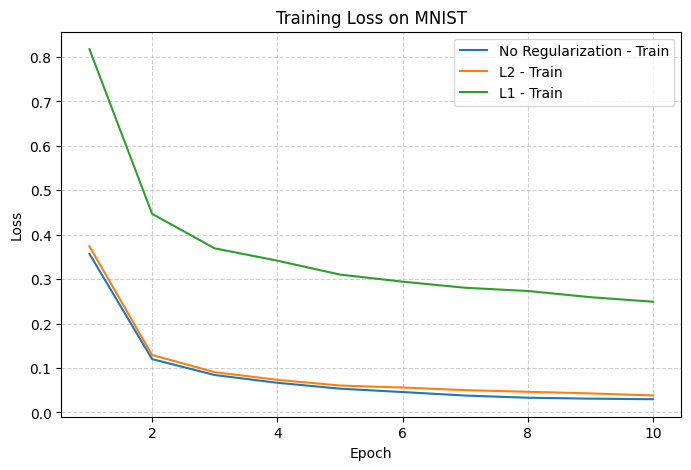

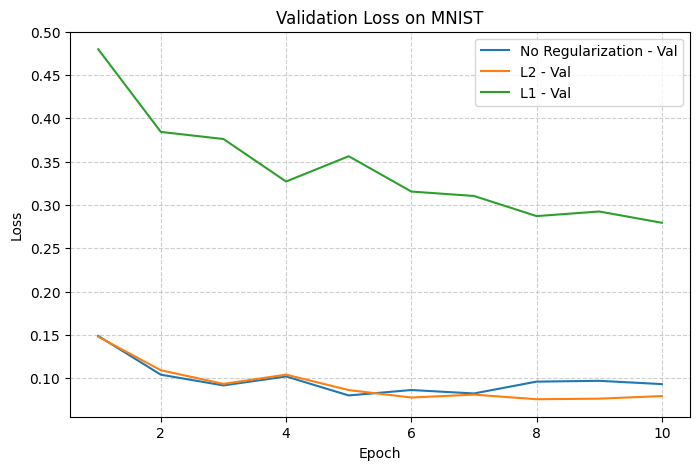

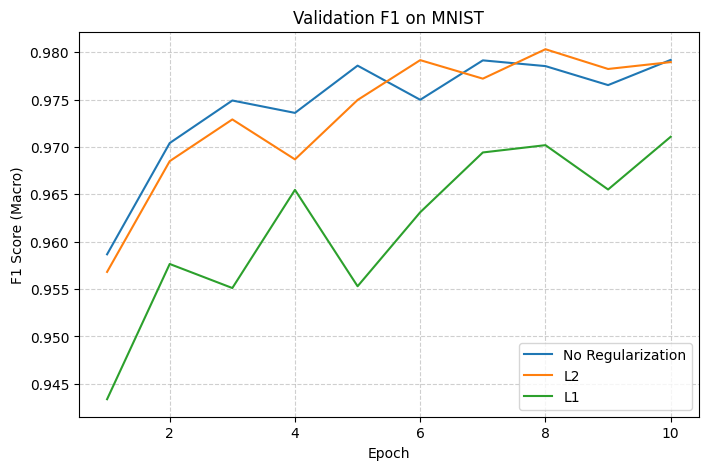

In [22]:
plot_metrics(
    train_losses=[loss_train_baseline, loss_train_l2, loss_train_l1],
    val_losses=[loss_val_baseline, loss_val_l2, loss_val_l1],
    f1_scores=[f1_baseline, f1_l2, f1_l1],
    init_names=["No Regularization", "L2", "L1"],
)

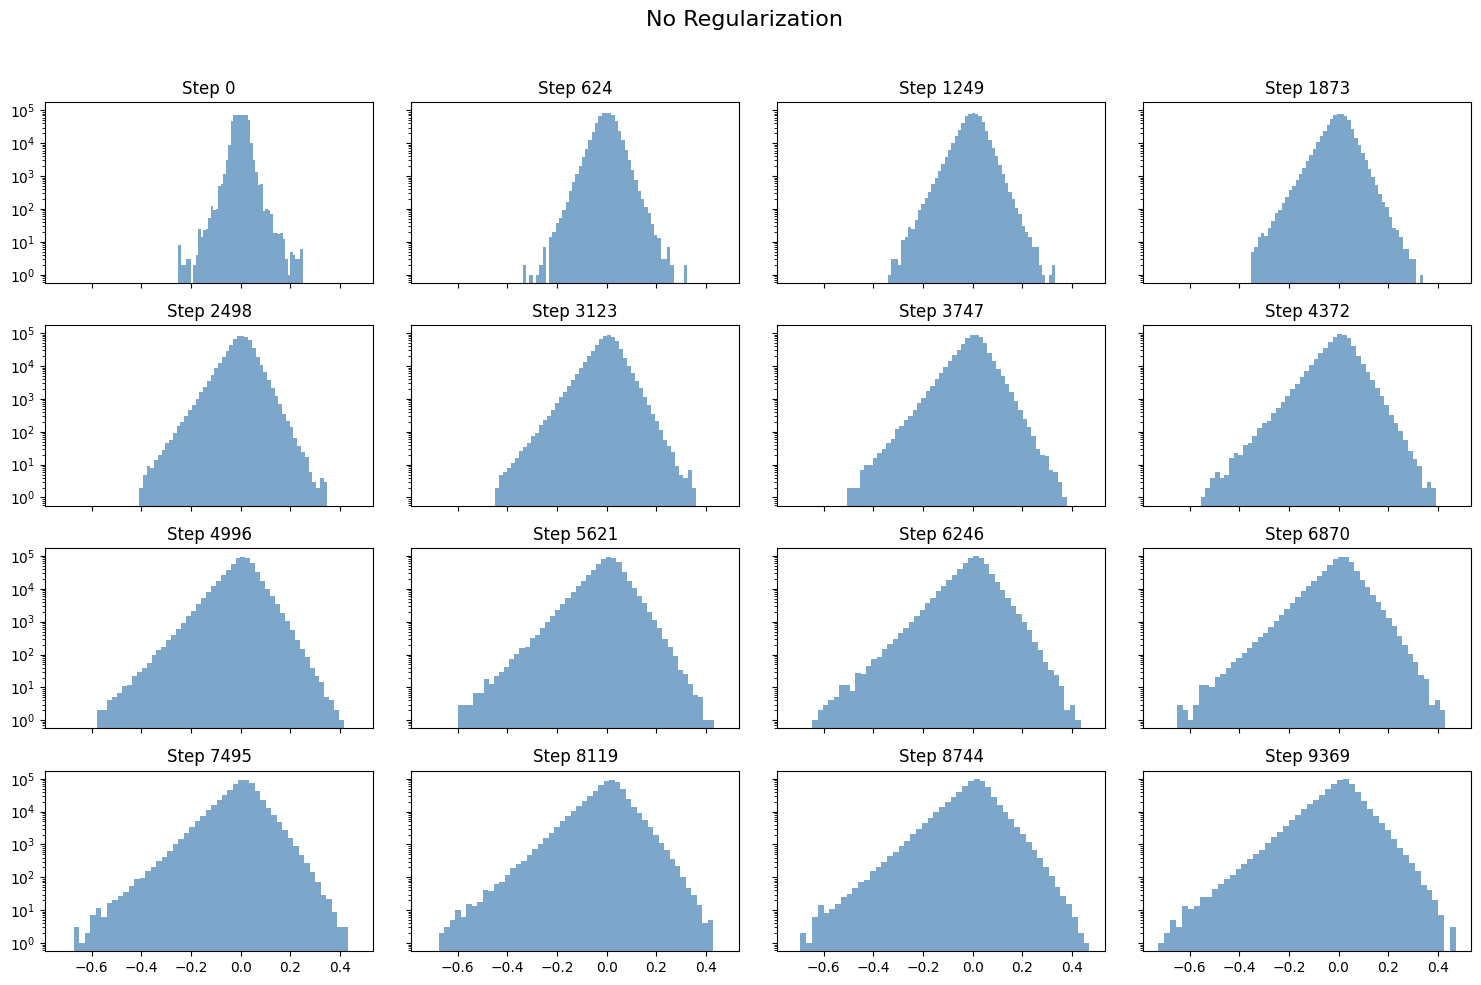

In [25]:
plot_weight_hist_grid(w_norms_baseline, max_plots=16, title="No Regularization")

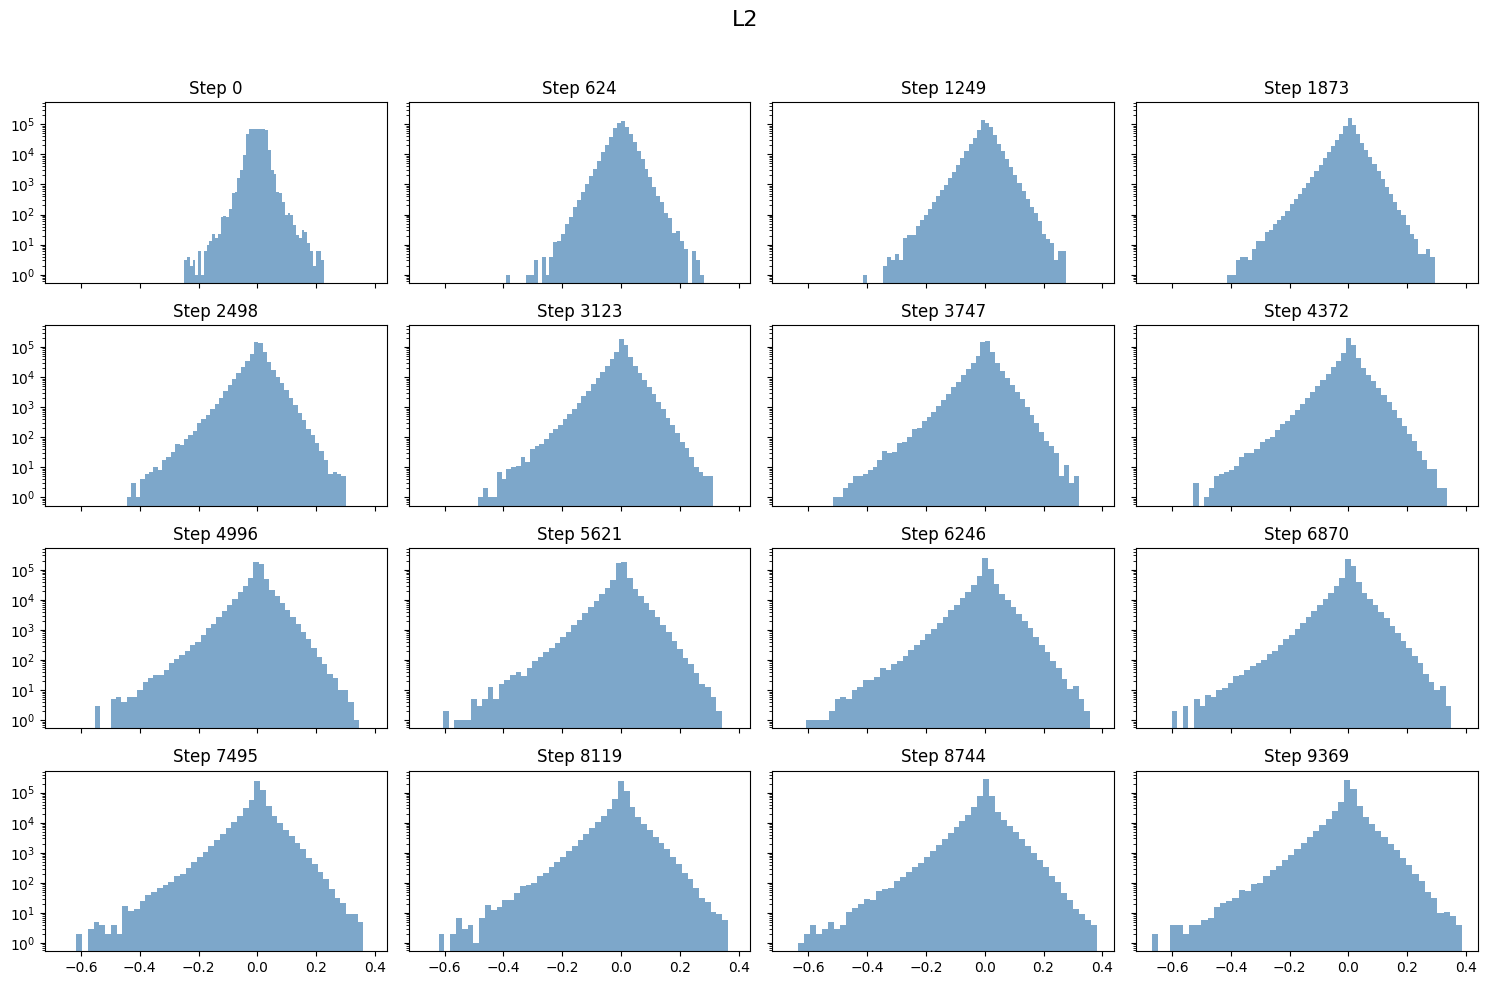

In [26]:
plot_weight_hist_grid(w_norms_l2, max_plots=16, title="L2")

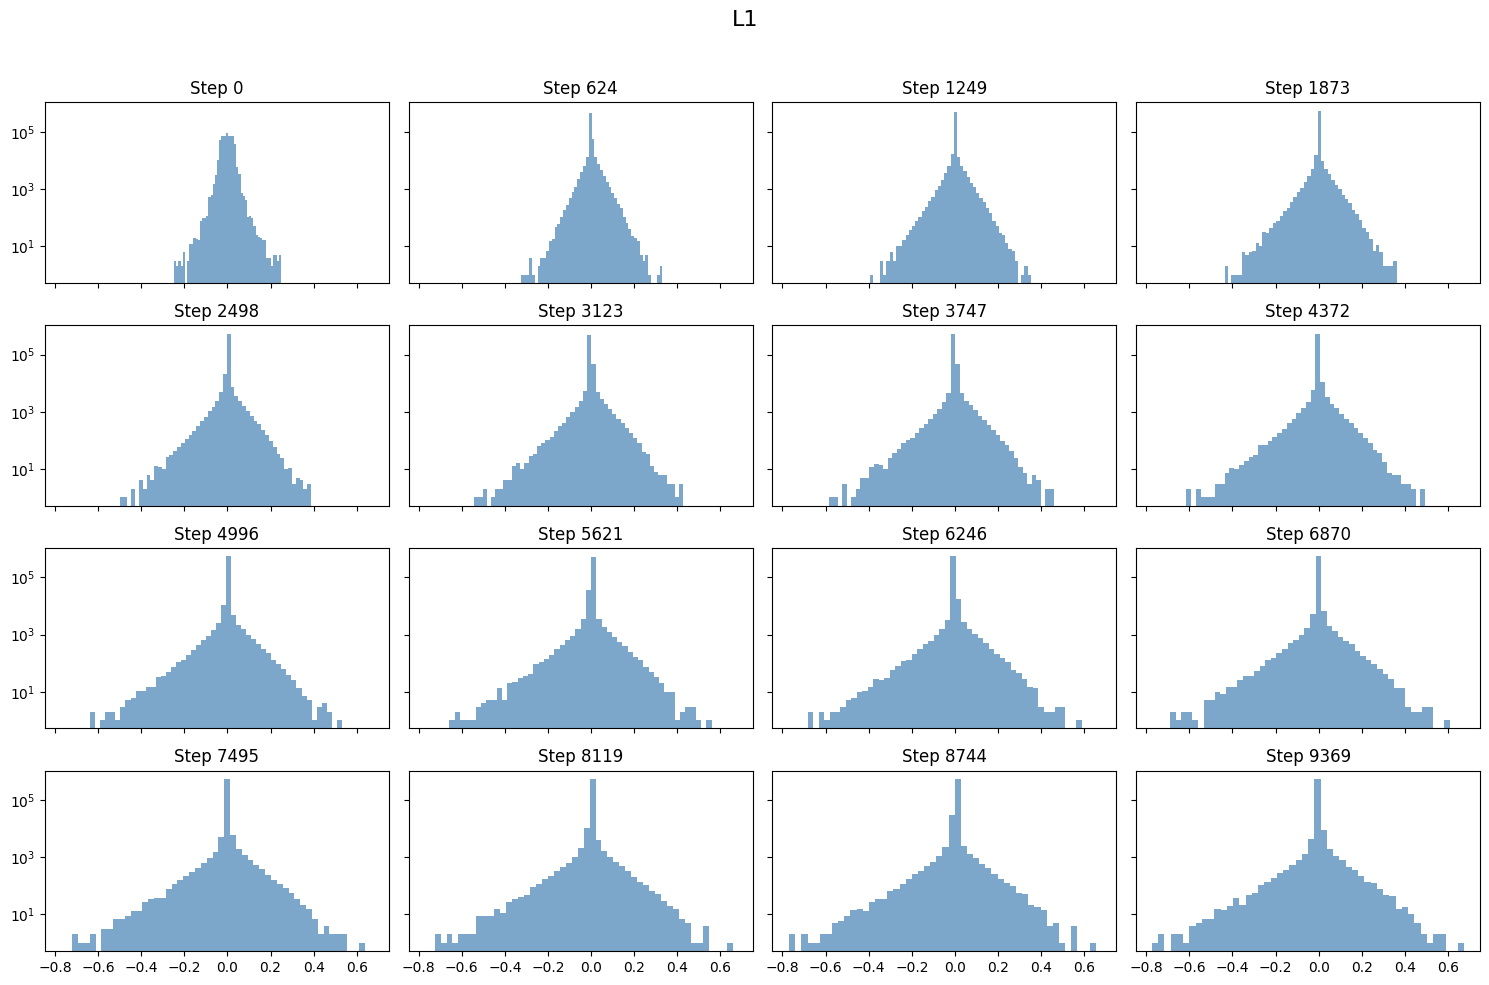

In [27]:
plot_weight_hist_grid(w_norms_l1, max_plots=16, title="L1")

<a id='Dropout'></a>
# Dropout

Dropout is a simple yet powerful regularization technique introduced in [“Improving neural networks by preventing co-adaptation of feature detectors” (Hinton et al., 2014)](https://arxiv.org/pdf/1207.0580) that aims to reduce overfitting by preventing complex co-adaptations of feature detectors.

---

### Intuition

- At **training time**, each hidden (and/or input) unit is *retained* with probability $p$ (the keep probability), and *dropped* (its activation set to zero) with probability $1 - p$.  
- Different “thinned” subnetworks are sampled in each batch. Because units cannot rely on specific others always being present, each learns more robust features.  
- At **test time**, all units are present. To match expected activations between training and test, either the weights are scaled (by factor $p$) or the activations during training are scaled (divided by $p$ for retained units). This ensures the expected output of each unit is consistent.  

---

### Formulas for Implementation

If $h$ is the activation of a hidden unit before dropout:

- **Train-time transformation (inverted dropout):**

$$
h' =
\begin{cases}
0 & \text{with probability } 1 - p \\
\frac{h}{p} & \text{with probability } p
\end{cases}
$$

- **Test-time behavior:** all units present, no dropout, no scaling needed under inverted dropout.

Alternatively, one can drop units without scaling at train time, and then scale activations by $p$ at test time.

---

### Additional Important Points

- Dropout acts like **model averaging**: training many subnetworks with shared weights; at test time you approximate the average of all these models.  
- Tuning $p$ is crucial: too low $p$ (too much dropout) → underfitting; too high $p$ (too little dropout) → insufficient regularization.  
- Dropout adds noise to training, slowing convergence, but improves generalization.  
- Often applied to hidden layers; sometimes to input layers (with higher $p$), less common in CNNs where parameter sharing already regularizes.

![Image Title](images/dropout_results.png)
*Taken from  [“Improving neural networks by preventing co-adaptation of feature detectors” (Hinton et al., 2014)](https://arxiv.org/pdf/1207.0580)*

> **CHECK**: Check the [next article](https://medium.com/data-science/simplified-math-behind-dropout-in-deep-learning-6d50f3f47275) about Dropout to figure out why we need activation scaling and what $p$ value is an optimal one 


In [44]:
class DeepMLPAdvanced(nn.Module):
    def __init__(self, use_dropout=False, use_bn=False, use_ln=False):
        super().__init__()

        def norm_layer(dim):
            if use_bn:
                return nn.BatchNorm1d(dim)
            elif use_ln:
                return nn.LayerNorm(dim)
            else:
                return nn.Identity()

        self.layers = nn.Sequential(
            nn.Linear(28*28, 512),
            norm_layer(512),
            nn.ReLU(),

            nn.Linear(512, 256),
            norm_layer(256),
            nn.ReLU(),

            nn.Linear(256, 128),
            norm_layer(128),
            nn.ReLU(),

            nn.Linear(128, 64),
            norm_layer(64),
            nn.ReLU(),
            nn.Dropout(0.5) if use_dropout else nn.Identity(),

            nn.Linear(64, 32),
            norm_layer(32),
            nn.ReLU(),
            nn.Dropout(0.2) if use_dropout else nn.Identity(),

            nn.Linear(32, 16),
            norm_layer(16),
            nn.ReLU(),

            nn.Linear(16, 10)  # output layer (no norm, no activation here)
        )

    def forward(self, x):
        x = x.view(-1, 28*28)
        return self.layers(x)


def train_MNIST_check_other_regularization(
    batch_size=64,
    n_epoch=10,
    device="cuda",
    use_dropout=False,
    use_bn=False,
    use_ln=False,
):
    # Data
    train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)
    
    # Initialize model
    model = DeepMLPAdvanced(use_dropout=use_dropout, use_bn=use_bn, use_ln=use_ln).to(device)
    print(model)
    
    # Initialize Optimizer 
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Initialize Scheduler 
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=(len(mnist_train)//batch_size) * n_epoch, eta_min=1e-5)
    
    train_loss_hist = []
    val_loss_hist = []
    f1_hist = []
    
    for epoch in tqdm(range(n_epoch)):
        epoch_loss = 0.0
        model.train()
        
        for Xi, yi in train_loader:
            outputs = model(Xi.to(device))
            loss = criterion(outputs, yi.to(device))
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            epoch_loss += loss.item() * Xi.shape[0]
        
        train_loss_hist.append(epoch_loss / len(mnist_train))

        # --- Validation ---
        model.eval()
        epoch_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for Xi, yi in test_loader:
                logits = model(Xi.to(device))
                val_loss = criterion(logits, yi.to(device))

                epoch_loss += val_loss.item() * Xi.shape[0]
                
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(yi.numpy())

        val_loss_hist.append(epoch_loss / len(mnist_test))
        f1_hist.append(f1_score(all_labels, all_preds, average="macro"))

    return train_loss_hist, val_loss_hist, f1_hist

In [38]:
loss_train_baseline, loss_val_baseline, f1_baseline = train_MNIST_check_other_regularization(
    n_epoch=40,
    use_dropout=False
)
loss_train_dropout, loss_val_dropout, f1_dropout = train_MNIST_check_other_regularization(
    n_epoch=40,
    use_dropout=True
)

DeepMLPAdvanced(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Identity()
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): ReLU()
    (11): Identity()
    (12): Linear(in_features=32, out_features=16, bias=True)
    (13): ReLU()
    (14): Linear(in_features=16, out_features=10, bias=True)
  )
)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [03:10<00:00,  4.77s/it]


DeepMLPAdvanced(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.5, inplace=False)
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=16, bias=True)
    (13): ReLU()
    (14): Linear(in_features=16, out_features=10, bias=True)
  )
)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [03:17<00:00,  4.93s/it]


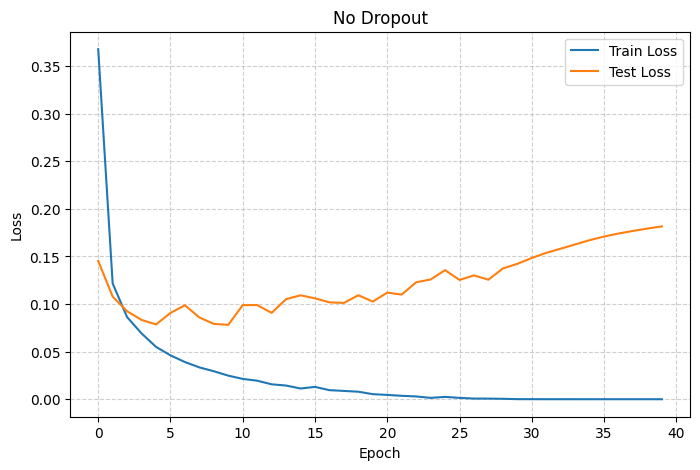

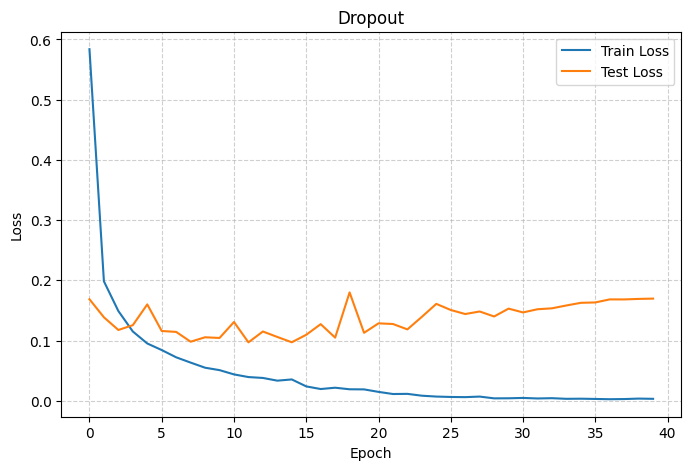

In [41]:
plt.figure(figsize=(8,5))
plt.plot(loss_train_baseline, label="Train Loss")
plt.plot(loss_val_baseline, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("No Dropout")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(loss_train_dropout, label="Train Loss")
plt.plot(loss_val_dropout, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dropout")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

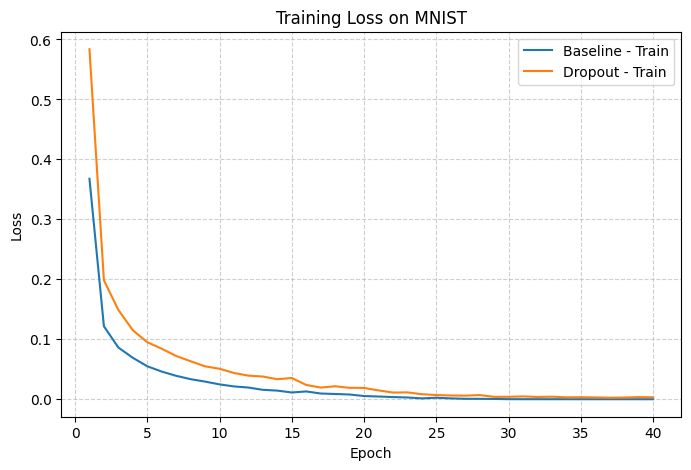

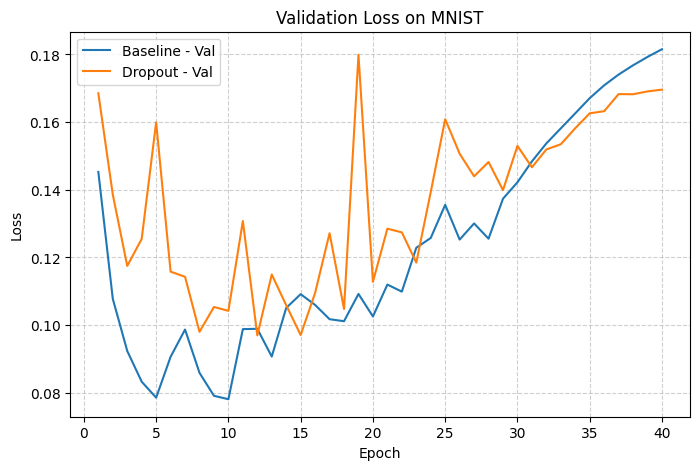

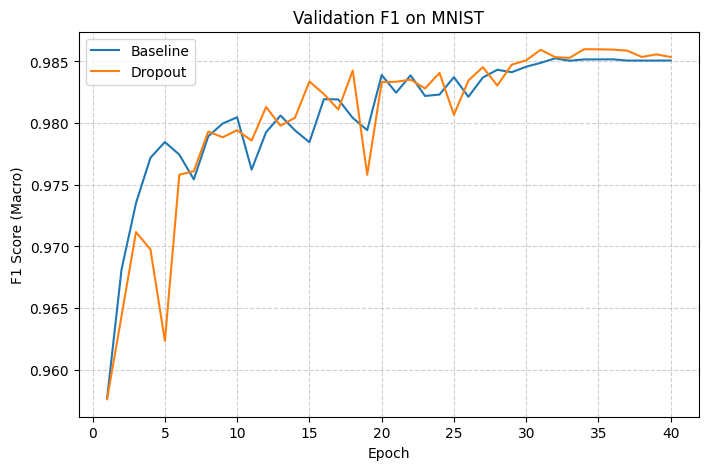

In [42]:
plot_metrics(
    train_losses=[loss_train_baseline, loss_train_dropout],
    val_losses=[loss_val_baseline, loss_val_dropout],
    f1_scores=[f1_baseline, f1_dropout],
    init_names=["Baseline", "Dropout"],
)

<a id='Batch_Layer_Normalization'></a>
# Batch/Layer Normalization

## Batch Normalization

Batch Normalization (BatchNorm) is a technique to accelerate and stabilize training of deep neural networks by reducing **internal covariate shift** — the change in the distribution of inputs to hidden layers during training. Introduced at [Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift](https://arxiv.org/abs/1502.03167)

---

### Problem
- In deep nets, as parameters in earlier layers change, the distribution of activations in later layers shifts.
- This slows down training, forces small learning rates, and can push activations into saturation regions of nonlinearities (vanishing gradients).

---

### Formulation

Given activations $x = (x^{(1)}, \dots, x^{(d)})$ in a mini-batch of size $m$:

1. **Mini-batch mean**  
   $$
   \mu_B^{(k)} = \frac{1}{m} \sum_{i=1}^m x_i^{(k)}
   $$

2. **Mini-batch variance**  
   $$
   (\sigma_B^{(k)})^2 = \frac{1}{m} \sum_{i=1}^m \big(x_i^{(k)} - \mu_B^{(k)}\big)^2
   $$

3. **Normalize**  
   $$
   \hat{x}_i^{(k)} = \frac{x_i^{(k)} - \mu_B^{(k)}}{\sqrt{(\sigma_B^{(k)})^2 + \epsilon}}
   $$

4. **Scale and shift** (learnable)  
   $$
   y_i^{(k)} = \gamma^{(k)} \hat{x}_i^{(k)} + \beta^{(k)}
   $$

- $\epsilon$ is a small constant for stability.  
- $\gamma, \beta$ are trainable parameters so the network can recover the original representation if needed.  

---

## Intuition / Benefits
- Stabilizes layer input distributions → faster convergence.  
- Allows **larger learning rates** and reduces sensitivity to initialization.  
- Acts as a **regularizer** (mini-batch statistics add noise).  
- Reduces or replaces the need for Dropout in some cases.  

---

## Practical Notes
- At **test time**, use *running averages* of mean/variance instead of batch statistics.  
- Too small batch sizes → noisy estimates → unstable training.  
- Typically applied **before the nonlinearity** (BN → ReLU).  

---

## Empirical Results
- On ImageNet, BatchNorm reduced training steps by up to **14×** while achieving the same accuracy.  
- Improved top-5 error rates in large vision models.  

![Image Title](images/bn_results.png)
*Taken from  [Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift](https://arxiv.org/abs/1502.03167)*


## Layer Normalization 

Layer Normalization was introduced in [Layer Normalization](https://arxiv.org/abs/1607.06450)

- Batch Normalization relies on statistics *across a mini-batch*. This can cause issues when batch size is small, or for recurrent neural networks where different sequence lengths / time-steps make batch statistics less stable. 
- Layer Normalization normalizes across the *features* of a single example, instead of across the batch. This means each training case is normalized independently, which solves many of the batch-dependence issues. 

---

### Formulation & Formula

Given an input vector $x \in \mathbb{R}^{d}$ (the pre-activations for one example across $d$ units in the layer):

- **Mean across features:**

$$
\mu = \frac{1}{d} \sum_{i=1}^{d} x_i
$$

- **Variance across features:**

$$
\sigma^2 = \frac{1}{d} \sum_{i=1}^{d} (x_i - \mu)^2
$$

- **Normalize:**

$$
\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}
$$

- **Scale and shift:**

$$
y_i = \gamma_i \hat{x}_i + \beta_i
$$

where $\gamma_i, \beta_i$ are learnable parameters (per feature), and $\epsilon$ is a small constant for numerical stability.

---

### Intuition & Benefits

- By normalizing across features for each example:
  - We remove dependence on other examples in the batch.
  - Makes training more stable when batch sizes are variable or small, or in recurrent settings where batch statistics would differ across time-steps.
- Same computation at training and test time (no need for running averages or different behavior). 
- Helps with stabilizing hidden state dynamics in RNNs; also useful in feedforward nets. 

---

### Important Practical Points / Limitations

- If features vary widely in scale, normalization can reduce useful signal — $\gamma$ and $\beta$ allow the model to restore it if needed.  
- Slightly more expensive than vanilla layers, as mean/variance are computed per example.  
- Less common in CNNs, but widely adopted in sequence models (e.g., **Transformers**). 

---

### Empirical Results & Use Cases

- The paper shows that LayerNorm speeds up training in RNNs (e.g. on language modeling tasks) compared with previous methods. 
- Used in many architectures where BatchNorm is less suitable, especially Transformers and other sequence models.

![Image Title](images/ln_results.png)
*Taken from  [Layer Normalization](https://arxiv.org/abs/1607.06450)*

In [45]:
loss_train_baseline, loss_val_baseline, f1_baseline = train_MNIST_check_other_regularization(
    n_epoch=10,
    use_bn=False,
    use_ln=False
)
loss_train_bn, loss_val_bn, f1_bn = train_MNIST_check_other_regularization(
    n_epoch=10,
    use_bn=True,
    use_ln=False
)
loss_train_ln, loss_val_ln, f1_ln = train_MNIST_check_other_regularization(
    n_epoch=10,
    use_bn=False,
    use_ln=True
)

DeepMLPAdvanced(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): Identity()
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): Identity()
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): Identity()
    (8): ReLU()
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): Identity()
    (11): ReLU()
    (12): Identity()
    (13): Linear(in_features=64, out_features=32, bias=True)
    (14): Identity()
    (15): ReLU()
    (16): Identity()
    (17): Linear(in_features=32, out_features=16, bias=True)
    (18): Identity()
    (19): ReLU()
    (20): Linear(in_features=16, out_features=10, bias=True)
  )
)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:49<00:00,  4.99s/it]


DeepMLPAdvanced(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Identity()
    (13): Linear(in_features=64, out_features=32, bias=True)
    (14): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): ReLU()
    (16): Identity()
    (17): Linear(in_features=32, out_features=16, bias=True)
    (18): BatchN

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:49<00:00,  4.98s/it]


DeepMLPAdvanced(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (11): ReLU()
    (12): Identity()
    (13): Linear(in_features=64, out_features=32, bias=True)
    (14): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (15): ReLU()
    (16): Identity()
    (17): Linear(in_features=32, out_features=16, bias=True)
    (18): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    (19): ReLU()
    (20): Linear(in_features=16, out_features=10, bias=True)
  )
)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:51<00:00,  5.19s/it]


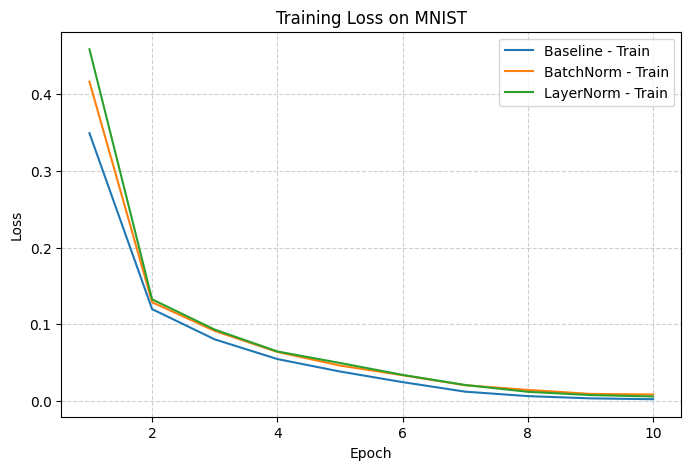

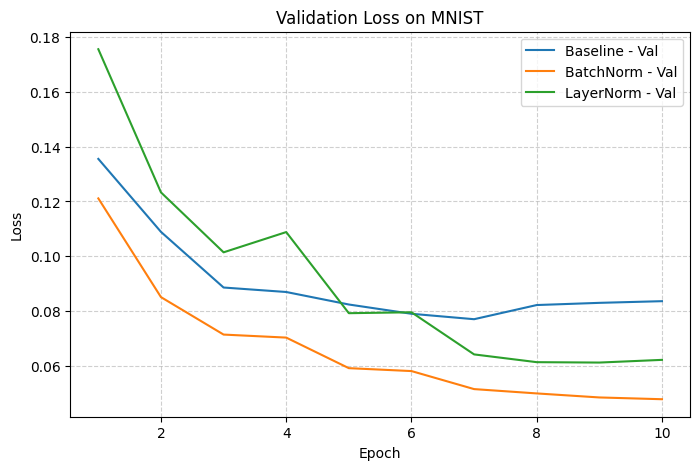

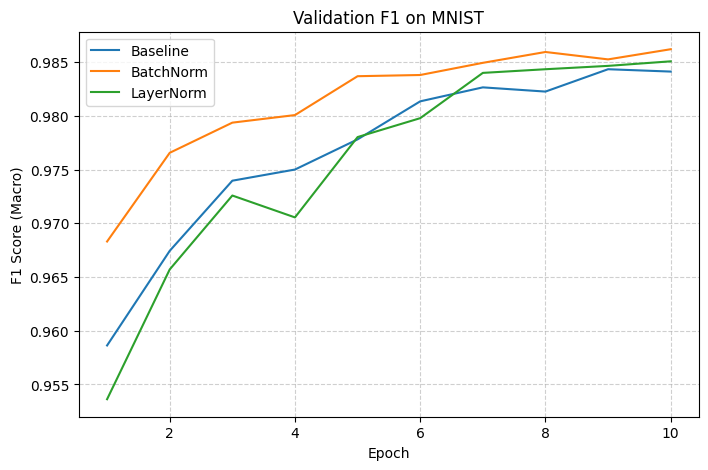

In [46]:
plot_metrics(
    train_losses=[loss_train_baseline, loss_train_bn, loss_train_ln],
    val_losses=[loss_val_baseline, loss_val_bn, loss_val_ln],
    f1_scores=[f1_baseline, f1_bn, f1_ln],
    init_names=["Baseline", "BatchNorm", "LayerNorm"],
)

<a id='Other_Types_of_Regularization'></a>
# Other Types of Regularization

Beyond weight penalties, Dropout, and normalization methods, there are several additional techniques to reduce overfitting:

- **Early Stopping:** Monitor validation error during training and stop once it stops improving. This prevents the model from fitting noise in the training data while keeping the parameters close to their best generalization point. Formally, we save parameters $\theta^*$ at epoch $t^*$ where validation loss is minimal, and restore them after training.  

- **Data Augmentation:** Expand the training set by applying transformations (rotations, flips, noise, masking, time-stretching in audio, etc.). This increases effective data diversity and reduces overfitting by forcing the model to generalize across variations.  

- **Ensembling:** Train multiple models (or snapshots of the same model) and average their predictions. This reduces variance and often improves robustness and accuracy. Dropout can be viewed as a computationally cheap approximation to ensembling.  

- **Stochastic Depth / ShakeDrop (for very deep nets):** Randomly skip entire layers during training, which acts as structured dropout and reduces co-adaptation across layers.  

- **Label Smoothing:** Instead of training with hard one-hot targets, assign a small probability mass to non-true classes. This regularizes the classifier by preventing it from becoming overconfident.  